In [150]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [151]:
dados = pd.read_csv(r'C:\Users\ashto\OneDrive\Documents\Python_\Cálculo_Numérico\Grupo02 (1).csv', sep =';')
dados['Precipitação'] = dados['Precipitação'].str.replace(',','.').astype(float)
dados

,Mês,Precipitação
0,1,144.4
1,2,150.0
2,3,125.8
3,4,94.0
4,5,111.0
5,6,262.2
6,7,149.8
7,8,186.0
8,9,188.4
9,10,231.3


In [152]:
x_dados = dados['Mês']
y_dados = dados['Precipitação']

In [153]:
# x => mês
# A0, A1, B1 coeficientes

def modelo_trigonometrico(x, A0, A1, B1):
    """
    período fixo em 12 meses
    """
    
    return A0 + A1*np.cos(2*np.pi * x /12) + B1 *np.sin(2*np.pi *x /12)


# curve_fit usa o metodo dos minimos quadrados para encontrar os melhores coeficientes A0, A1, B1
# `popt` conterá os coeficientes ótimos [A0, A1, B1]
# `pcov` é a matriz de covariância, que pode ser usada para calcular a incerteza dos parâmetros.
params_otimos, pcov = curve_fit(modelo_trigonometrico, x_dados, y_dados)

A0_fit, A1_fit, B1_fit = params_otimos
print("--- Coeficientes Encontrados ---")
print(f"A0 (Média de precipitação ajustada): {A0_fit:.2f}")
print(f"A1 (Coeficiente do cosseno): {A1_fit:.2f}")
print(f"B1 (Coeficiente do seno): {B1_fit:.2f}")
print("\nFunção final F(x) = {:.2f} + {:.2f}*cos(2*pi*x/12) + {:.2f}*sin(2*pi*x/12)".format(A0_fit, A1_fit, B1_fit))

--- Coeficientes Encontrados ---
A0 (Média de precipitação ajustada): 133.36
A1 (Coeficiente do cosseno): 28.24
B1 (Coeficiente do seno): -60.72

Função final F(x) = 133.36 + 28.24*cos(2*pi*x/12) + -60.72*sin(2*pi*x/12)



--- Previsão ---
A precipitação estimada para o mês 72 é: 161.60 mm


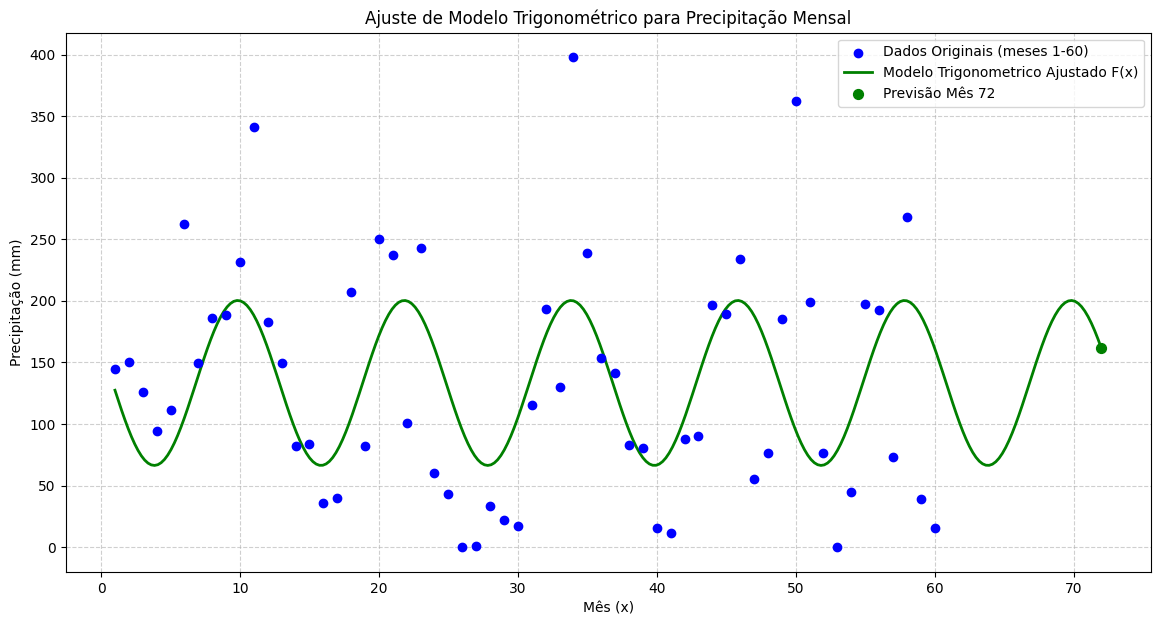

In [154]:
#visualizar

x_curva = np.linspace(1,72,300)
y_curva = modelo_trigonometrico(x_curva, *params_otimos) # * para desempacotar

plt.figure(figsize=(14,7))
plt.scatter(x_dados,y_dados,label='Dados Originais (meses 1-60)', color = 'blue', zorder=5)
plt.plot(x_curva,y_curva, label='Modelo Trigonometrico Ajustado F(x)', color ='green', linewidth = 2)

plt.title('Ajuste de Modelo Trigonométrico para Precipitação Mensal')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

mes_futuro = 72
precipitacao_prevista = modelo_trigonometrico(mes_futuro,*params_otimos)
print(f"\n--- Previsão ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:.2f} mm")

plt.scatter(mes_futuro, precipitacao_prevista, color='green', marker='.', s=200, label=f'Previsão Mês {mes_futuro}', zorder=10)
plt.legend()
plt.show()

--- Previsão para o Mês 72 (para cada ordem) ---
Ordem 1: 161.60 mm
Ordem 2: 141.88 mm
Ordem 3: 116.34 mm
Ordem 4: 103.82 mm


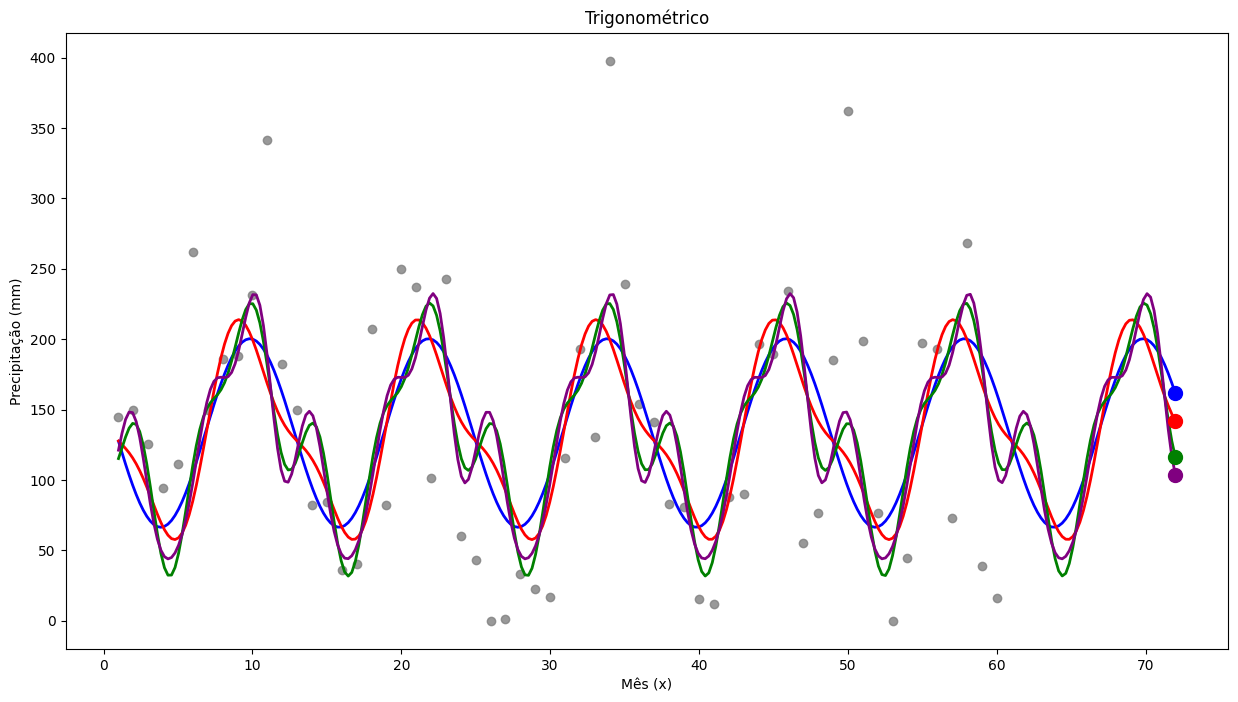

In [155]:
m = len(x_dados)

# --- A Função de Modelo Geral ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        termo_cos = Ak * np.cos(2 * np.pi * ordem_k * x / 12)
        termo_sin = Bk * np.sin(2 * np.pi * ordem_k * x / 12)
        y = y + termo_cos + termo_sin
    return y

# --- Loop para Testar Ordens e Mostrar Previsões ---
plt.figure(figsize=(15, 8))
plt.scatter(x_dados, y_dados, label='Dados Originais', color='gray', alpha=0.8)

print("--- Previsão para o Mês 72 (para cada ordem) ---")

# Lista de cores para as curvas e pontos
cores = ['blue', 'red', 'green', 'purple']

for i, ordem_n in enumerate(range(1, 5)):
    num_params = 1 + 2 * ordem_n
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem_n)
    
    try:
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        
        # Plotar a curva do modelo
        x_curva = np.linspace(1, 72, 300)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        cor_atual = cores[i % len(cores)] # Seleciona a cor
        plt.plot(x_curva, y_curva, label=f'Ordem {ordem_n}', color=cor_atual, linewidth=2)
        
        # Calcular e mostrar a previsão para esta ordem
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        print(f"Ordem {ordem_n}: {precipitacao_prevista:.2f} mm")
        
        # Destacar o ponto da previsão no gráfico
        plt.scatter(mes_futuro, precipitacao_prevista, color=cor_atual, marker='o', s=100, zorder=10)

    except RuntimeError:
        print(f"Ordem {ordem_n}: Não foi possível ajustar o modelo.")

# --- Finalizar o gráfico ---
plt.title('Trigonométrico')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
# plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Interpolação polinomial -> não faz sentido pois explode

Ajustando um polinômio de grau 59...

--- Previsão com Interpolação Polinomial ---
A precipitação estimada para o mês 72 é: 1.085978e+15


C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\3414194276.py:23: RankWarning: Polyfit may be poorly conditioned
  coeficientes = np.polyfit(x_dados, y_dados, grau_polinomio)


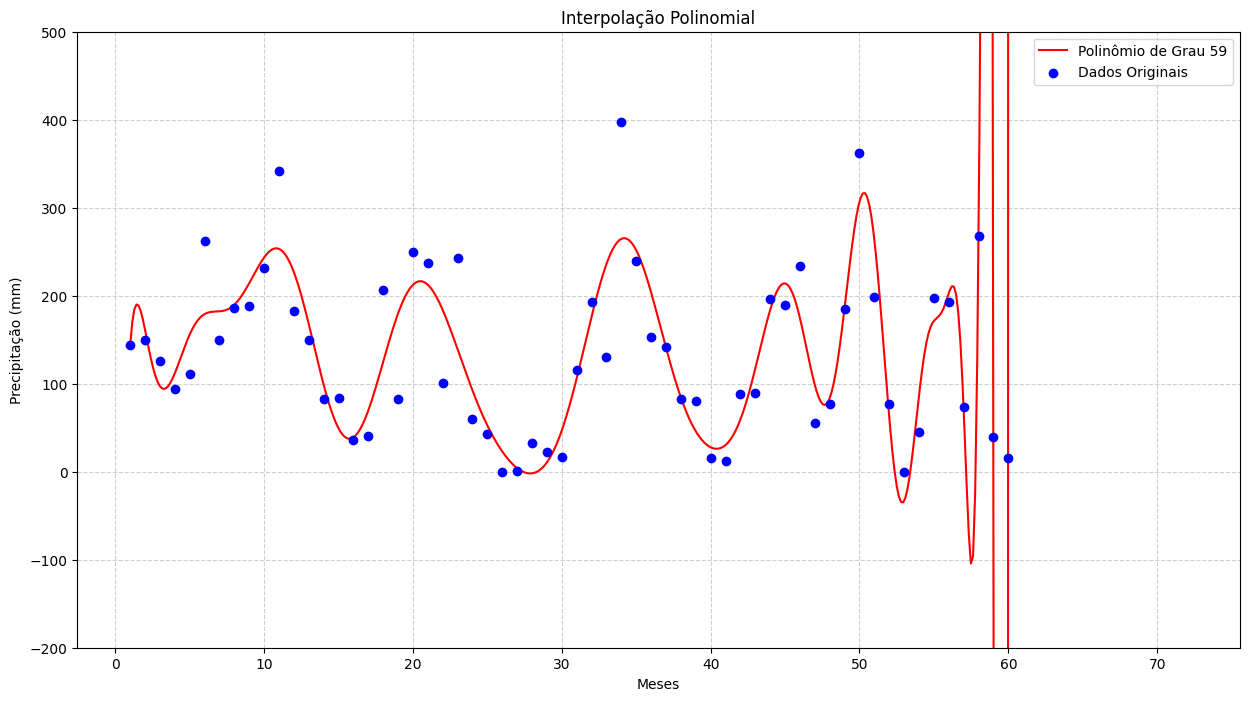

In [156]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Interpolação Polinomial ---
# Para 60 pontos, o grau do polinômio que passa por todos é 59.
grau_polinomio = 59

print(f"Ajustando um polinômio de grau {grau_polinomio}...")

# 1. Encontrar os coeficientes do polinômio
# A função pode emitir um aviso "Polyfit may be poorly conditioned", o que é esperado.
coeficientes = np.polyfit(x_dados, y_dados, grau_polinomio)

# 2. Criar a função polinomial a partir dos coeficientes
polinomio_interpolador = np.poly1d(coeficientes)

# 3. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = polinomio_interpolador(mes_futuro)

print(f"\n--- Previsão com Interpolação Polinomial ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:e}") # Usando notação científica

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Plotar a curva interpolada
x_curva = np.linspace(1, 72, 500)
y_curva = polinomio_interpolador(x_curva)
plt.plot(x_curva, y_curva, label=f'Polinômio de Grau {grau_polinomio}', color='red')

# Plotar os dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)

plt.title('Interpolação Polinomial')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)

# ATENÇÃO: Vamos limitar o eixo Y para podermos ver os dados originais.
# A curva polinomial "explode" para valores muito altos/baixos.
plt.ylim(-200, 500) # Ajuste este limite para conseguir ver a curva vs. os pontos
plt.legend()
plt.show()

Lagrange => não faz sentido pois explode, obedece a todos os ruídos e, por isso, seu comportamento fora do intervalo dos dados é caótico e imprevisível.

Construindo o polinômio interpolador de Lagrange...

--- Previsão com Interpolação de Lagrange ---
A precipitação estimada para o mês 72 é: 9.090950e+39


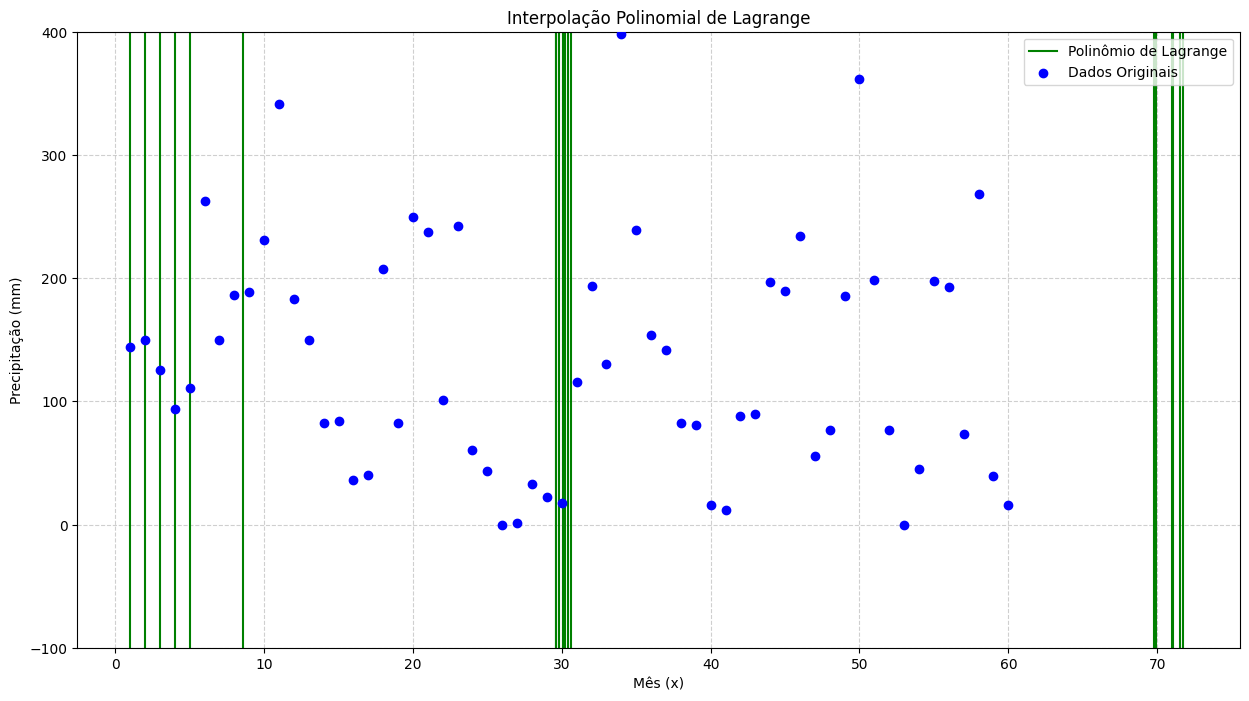

In [157]:
import numpy as np
from scipy.interpolate import lagrange
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

print("Construindo o polinômio interpolador de Lagrange...")

# 1. A função lagrange já retorna o objeto de polinômio pronto para uso.
# É mais direto que o polyfit, que retorna apenas os coeficientes.
polinomio_lagrange = lagrange(x_dados, y_dados)

# 2. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = polinomio_lagrange(mes_futuro)

print(f"\n--- Previsão com Interpolação de Lagrange ---")
# O resultado será idêntico ao do polyfit, pois o polinômio interpolador é único.
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:e}")

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Plotar a curva interpolada
x_curva = np.linspace(1, 72, 500)
y_curva = polinomio_lagrange(x_curva)
plt.plot(x_curva, y_curva, label='Polinômio de Lagrange', color='green')

# Plotar os dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)

plt.title('Interpolação Polinomial de Lagrange')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-200, 500) # Limitando o eixo Y para visualizar os dados
plt.legend()
plt.ylim(-100, 400)
plt.show()

Interpolação linear => Não faz sentido pois simplesmente conecta pontos de dados consecutivos com uma linha reta. O resultado não é uma única curva suave, mas uma série de segmentos de retas

Criando a função de interpolação linear...

--- Previsão com Interpolação Linear ---
A precipitação estimada para o mês 72 é: -262.60 mm


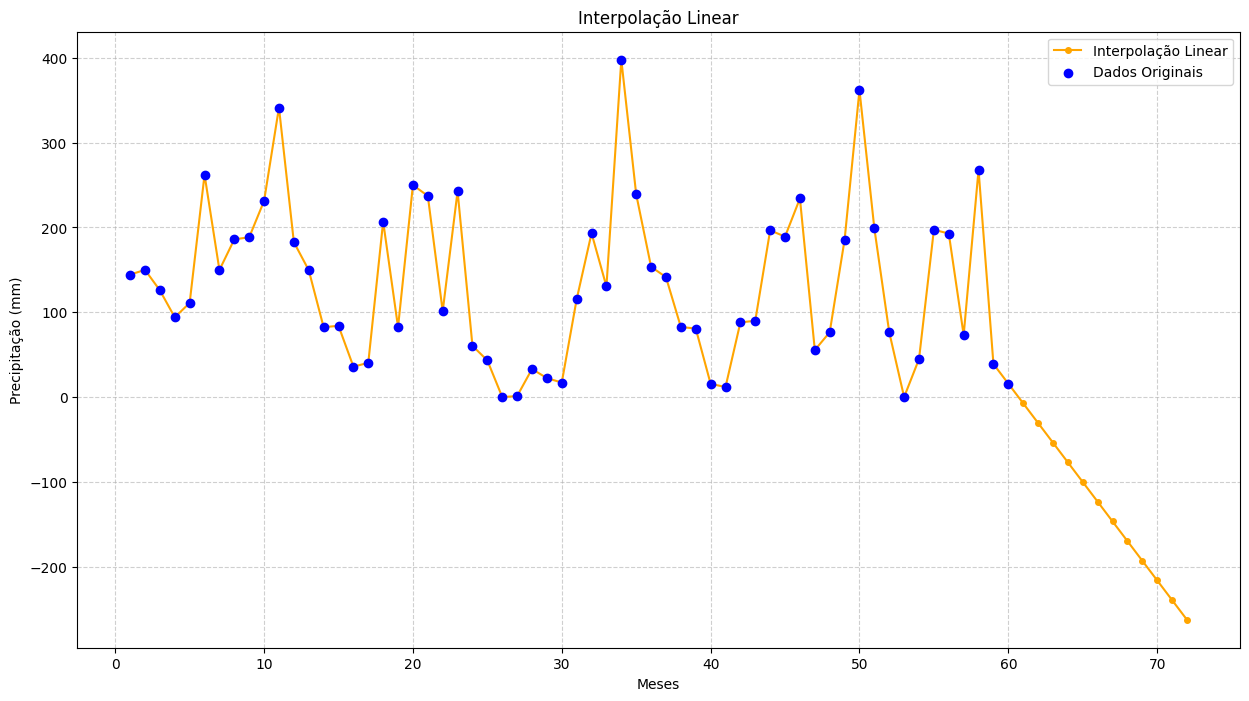

In [158]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

print("Criando a função de interpolação linear...")

# 1. Criar a função de interpolação
# 'kind='linear'' é o padrão, mas deixamos explícito.
# 'fill_value="extrapolate"' permite que a função faça previsões fora do intervalo [1, 60].
funcao_linear = interp1d(x_dados, y_dados, kind='linear', fill_value="extrapolate")

# 2. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = funcao_linear(mes_futuro)

print(f"\n--- Previsão com Interpolação Linear ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:.2f} mm")

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Plotar a curva interpolada
# Usamos os dados originais para x para mostrar os segmentos de reta
x_curva = np.arange(1, 73) # Vai até o mês 72
y_curva = funcao_linear(x_curva)
plt.plot(x_curva, y_curva, label='Interpolação Linear', color='orange', marker='o', markersize=4)

# Plotar os dados originais
plt.scatter(x_dados, y_dados, color='blue', zorder=5, label='Dados Originais')

plt.title('Interpolação Linear')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Diferenças divididas => não faz sentido pois tambem explode, é uma aproximação exata


 O seu objetivo é a aproximação e extrapolação – encontrar uma tendência geral em dados "ruidosos" e prever o futuro. São objetivos conflitantes.

Calculando o polinômio via Diferenças Divididas de Newton...

--- Previsão com Diferenças Divididas de Newton ---
A precipitação estimada para o mês 72 é: 2.957245e+31


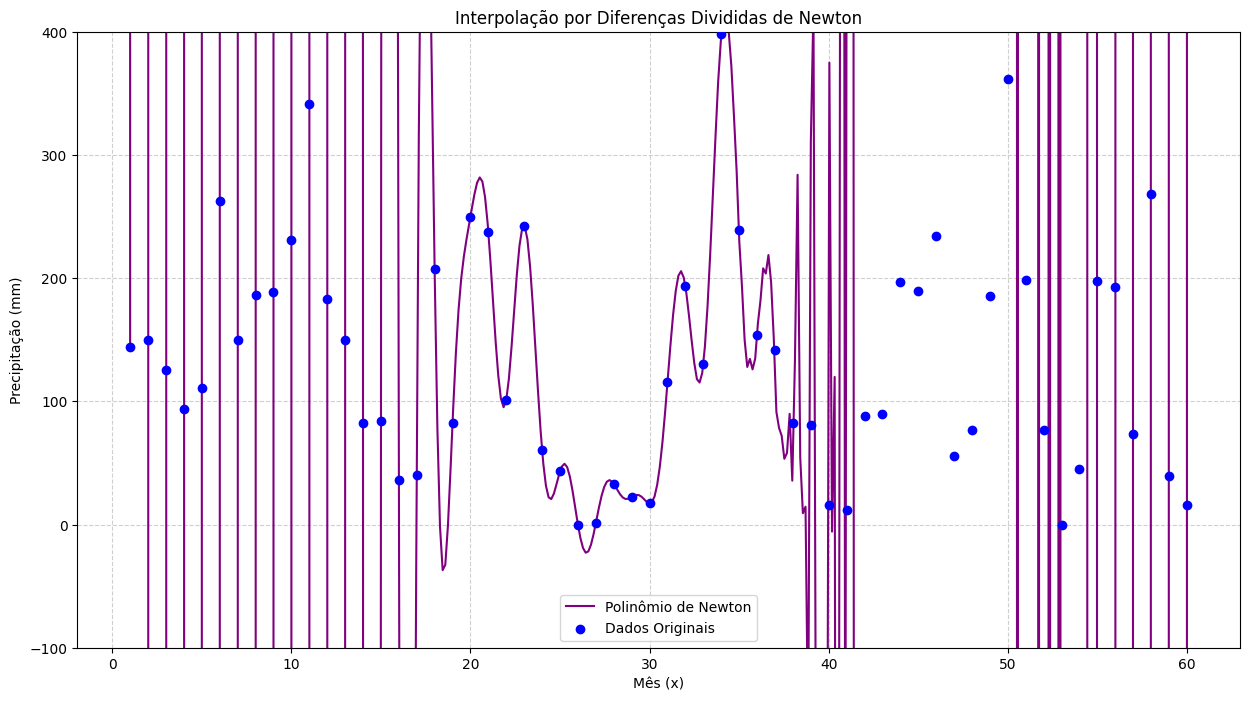

In [159]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Implementação do Método de Diferenças Divididas de Newton ---

def calcular_coeficientes(x, y):
    """
    Calcula os coeficientes (a diagonal da tabela de diferenças divididas).
    """
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y # A primeira coluna é y
    
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
            
    return coef[0, :] # Retorna a primeira linha (c0, c1, c2, ...)

def avaliar_polinomio(coef, x_data, x_eval):
    """
    Avalia o polinômio na forma de Newton em um ponto x_eval.
    """
    n = len(coef) - 1
    p = coef[n]
    for k in range(1, n + 1):
        p = coef[n - k] + (x_eval - x_data[n - k]) * p
    return p

print("Calculando o polinômio via Diferenças Divididas de Newton...")

# 1. Calcular os coeficientes c0, c1, ...
coeficientes_newton = calcular_coeficientes(x_dados, y_dados)

# 2. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = avaliar_polinomio(coeficientes_newton, x_dados, mes_futuro)

print(f"\n--- Previsão com Diferenças Divididas de Newton ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:e}")

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Avaliar o polinômio em vários pontos para plotar a curva
x_curva = np.linspace(1, 60, 400) # Evitamos extrapolar no plot para não distorcer a escala
y_curva = [avaliar_polinomio(coeficientes_newton, x_dados, x) for x in x_curva]
plt.plot(x_curva, y_curva, label='Polinômio de Newton', color='purple')

# Plotar os dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)

plt.title('Interpolação por Diferenças Divididas de Newton')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(-100, 400)
plt.show()

Formula de Newton-> igual diferenças divididas

Executando o método de interpolação de Newton...

A previsão para o mês 72 é: 2.957245e+31


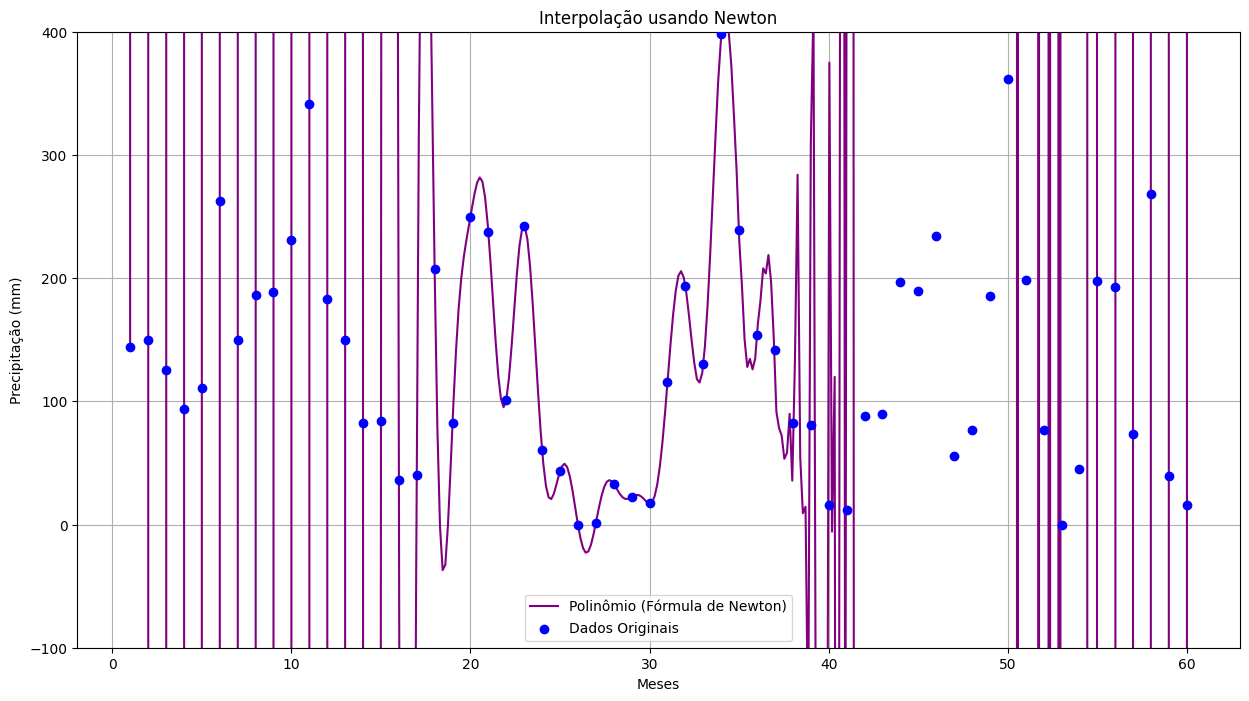

In [160]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# ==============================================================================
# PARTE 1: CALCULANDO OS "INGREDIENTES" (AS DIFERENÇAS DIVIDIDAS)
# ==============================================================================
def calcular_coeficientes_newton(x, y):
    """
    Esta função calcula os coeficientes c0, c1, c2, ... 
    que são as próprias diferenças divididas.
    """
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y
    
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
            
    return coef[0, :] # Os coeficientes são a primeira linha da tabela

# ==============================================================================
# PARTE 2: USANDO A "RECEITA" (A FÓRMULA DE NEWTON)
# ==============================================================================
def avaliar_com_formula_newton(coef, x_data, x_eval):
    """
    Esta função usa a Fórmula de Newton para montar o polinômio e calcular 
    seu valor em um ponto específico (x_eval), usando os coeficientes da Parte 1.
    P(x) = c0 + c1(x-x0) + c2(x-x0)(x-x1) + ...
    """
    n = len(coef) - 1
    p = coef[n] # Começa com o último coeficiente
    for k in range(1, n + 1):
        # Itera de trás para frente, construindo o polinômio
        p = coef[n - k] + (x_eval - x_data[n - k]) * p
    return p

# --- Executando o Processo Completo ---
print("Executando o método de interpolação de Newton...")

# 1. Obter os ingredientes (Diferenças Divididas)
coeficientes = calcular_coeficientes_newton(x_dados, y_dados)

# 2. Usar a receita (Fórmula de Newton) para prever o mês 72
mes_futuro = 72
precipitacao_prevista = avaliar_com_formula_newton(coeficientes, x_dados, mes_futuro)

print(f"\nA previsão para o mês {mes_futuro} é: {precipitacao_prevista:e}")

# 3. Usar a receita novamente para gerar o gráfico
x_curva = np.linspace(1, 60, 400)
y_curva = [avaliar_com_formula_newton(coeficientes, x_dados, x) for x in x_curva]

# --- Visualização ---
plt.figure(figsize=(15, 8))
plt.plot(x_curva, y_curva, label='Polinômio (Fórmula de Newton)', color='purple')
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)
plt.title('Interpolação usando Newton')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True)
plt.legend()
plt.ylim(-100,400)
plt.show()

MMQ Caso polinomial =>  Inadequada por não conseguir modelar a sazonalidade

faz mais sentido usar a trigonometrica, pois podemos usar uma periódicidade

--- Previsões com MMQ Polinomial para o Mês 72 ---
Grau 1: 108.74 mm
Grau 2: 152.05 mm
Grau 3: 71.73 mm
Grau 4: -519.90 mm
Grau 10: -31924.69 mm


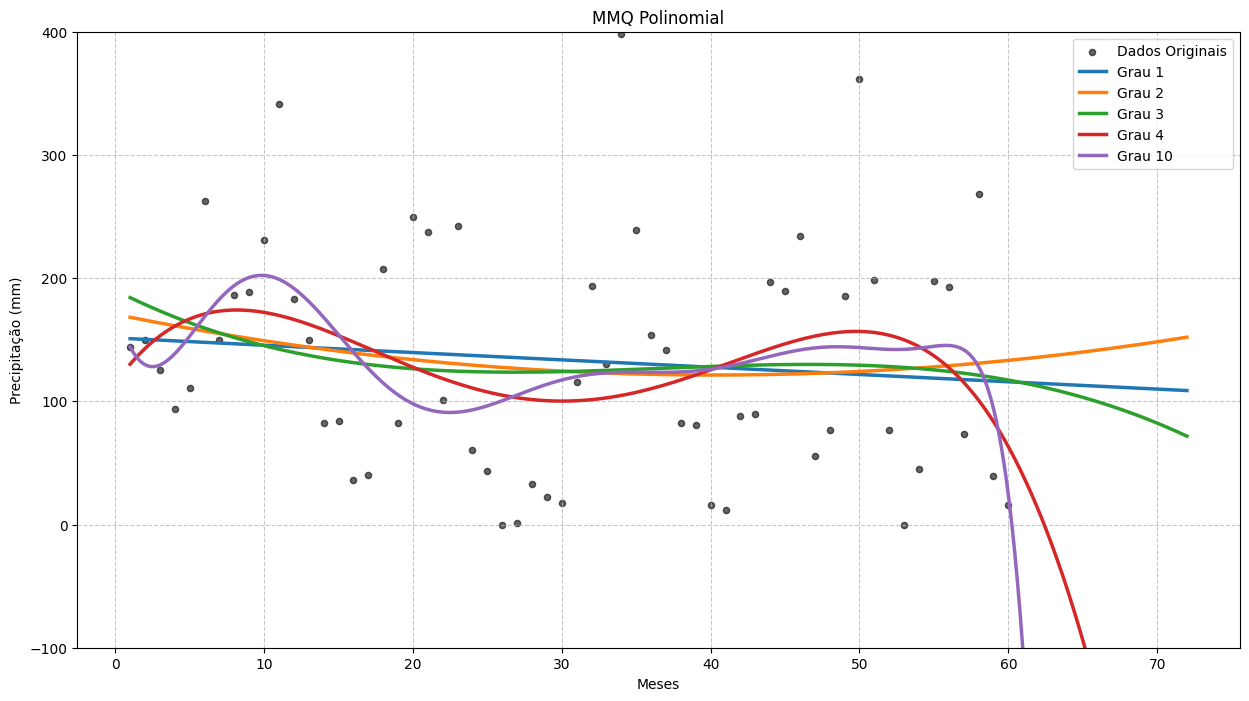

In [161]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])


# --- Estrutura Principal do Gráfico Comparativo ---

# 1. Criar a figura e os eixos UMA VEZ
plt.figure(figsize=(15, 8))
# 2. Plotar os dados originais UMA VEZ
plt.scatter(x_dados, y_dados, label='Dados Originais', color='black', alpha=0.6, s=20)

print("--- Previsões com MMQ Polinomial para o Mês 72 ---")

# Vamos testar alguns graus baixos e um grau um pouco mais alto para ver o overfitting
graus_a_testar = [1, 2, 3, 4, 10] 

# 3. Loop para calcular e plotar cada modelo polinomial
for grau in graus_a_testar:
    
    # Ajustar o polinômio de grau baixo usando MMQ
    coeficientes = np.polyfit(x_dados, y_dados, grau)
    polinomio_mmq = np.poly1d(coeficientes)
    
    # Gerar a curva de tendência
    x_curva = np.linspace(1, 72, 400)
    y_curva = polinomio_mmq(x_curva)
    
    # Plotar a curva do modelo atual no mesmo gráfico
    plt.plot(x_curva, y_curva, label=f'Grau {grau}', linewidth=2.5)
    
    # Calcular e imprimir a previsão
    mes_futuro = 72
    precipitacao_prevista = polinomio_mmq(mes_futuro)
    print(f"Grau {grau}: {precipitacao_prevista:.2f} mm")


# 4. Configurar os detalhes do gráfico DEPOIS do loop
plt.title('MMQ Polinomial')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.ylim(-100, 400)
plt.show()

In [162]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Função que gera o gráfico com base no grau escolhido ---
def plotar_polinomio_por_grau(grau):
    """
    Esta função é chamada toda vez que você move o slider.
    Ela ajusta um polinômio do 'grau' especificado e plota o resultado.
    """
    
    # Prevenir avisos de instabilidade para graus muito altos
 
    # 1. Ajustar o polinômio (MMQ)
    coeficientes = np.polyfit(x_dados, y_dados, grau)
    polinomio_mmq = np.poly1d(coeficientes)
    
    # 2. Gerar a curva para o plot
    x_curva = np.linspace(1, 72, 400)
    y_curva = polinomio_mmq(x_curva)
    
    # 3. Fazer a previsão para o mês 72
    mes_futuro = 72
    precipitacao_prevista = polinomio_mmq(mes_futuro)
    
    # 4. Plotar tudo
    plt.figure(figsize=(14, 7))
    plt.scatter(x_dados, y_dados, label='Dados Originais', color='gray', alpha=0.7)
    plt.plot(x_curva, y_curva, label=f'Curva do Polinômio (Grau {grau})', color='red')
    
    plt.title(f'MMQ Polinomial de Grau {grau}')
    plt.xlabel('Mês (x)')
    plt.ylabel('Precipitação (mm)')
    
    # Adicionar o texto da previsão dentro do gráfico
    # Usamos try/except para o caso de a previsão ser um número enorme
    try:
        texto_previsao = f'Previsão Mês 72: {precipitacao_prevista:.2f} mm'
    except OverflowError:
        texto_previsao = 'Previsão Mês 72: Valor muito grande (explosão)'
        
    plt.text(5, 400, texto_previsao, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    
    # Limitamos o eixo Y para que o gráfico não "exploda" com graus altos
    plt.ylim(-150, 500)
    plt.grid(True)
    plt.legend()
    plt.show()

# --- Criando a Interatividade ---
# O 'interact' cria um slider para o argumento 'grau' da nossa função
interact(plotar_polinomio_por_grau, 
         grau=widgets.IntSlider(value=2, min=0, max=59, step=1, description='Grau do Polinômio:'));

interactive(children=(IntSlider(value=2, description='Grau do Polinômio:', max=59), Output()), _dom_classes=('…

MMQ - trigonométrico => melhor opção

--- Previsões para o Mês 72 (por ordem) ---
Ordem 1: 161.60 mm
Ordem 2: 141.88 mm
Ordem 3: 116.34 mm
Ordem 4: 103.82 mm
Ordem 5: 88.10 mm


C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\28615503.py:42: OptimizeWarning: Covariance of the parameters could not be estimated
  params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)


Ordem 6: 97.78 mm


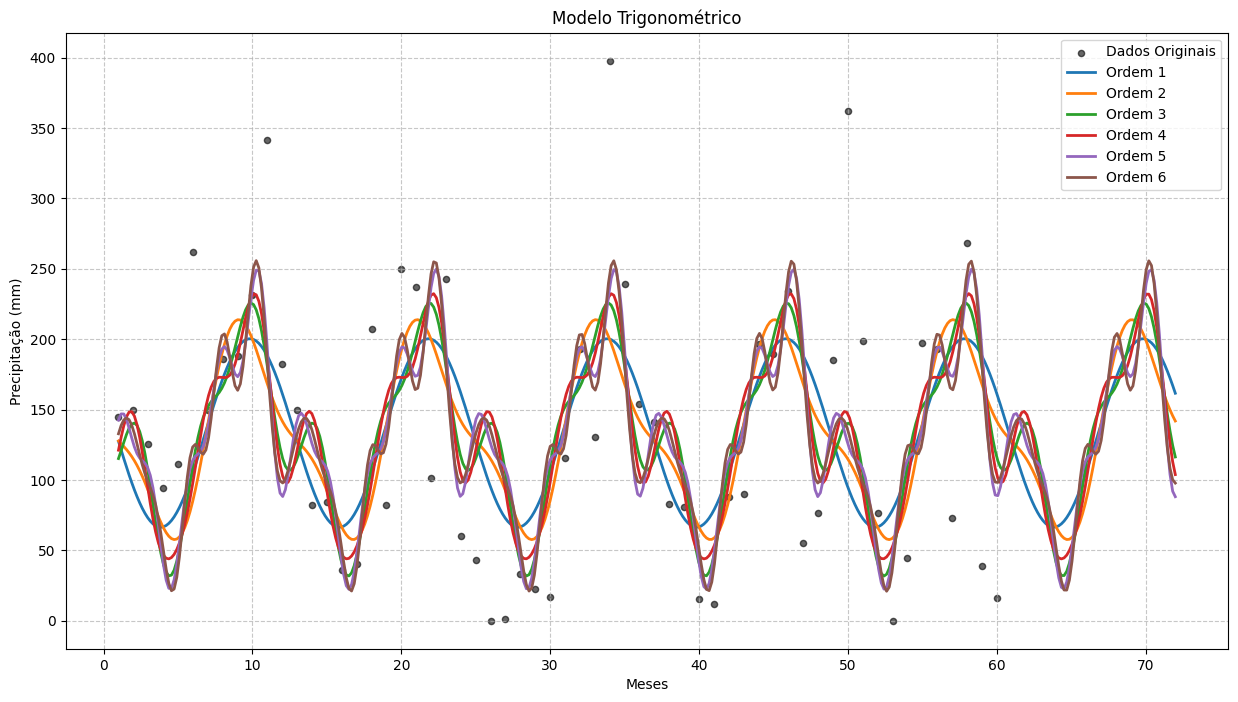

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Função de Modelo Trigonométrico Geral (a mesma de antes) ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        y += Ak * np.cos(2 * np.pi * ordem_k * x / 12) + Bk * np.sin(2 * np.pi * ordem_k * x / 12)
    return y

# --- Estrutura Principal do Gráfico ---

# 1. Criar a figura e os eixos UMA VEZ, antes do loop
plt.figure(figsize=(15, 8))
# 2. Plotar os dados originais UMA VEZ
plt.scatter(x_dados, y_dados, label='Dados Originais', color='black', alpha=0.6, s=20)

print("--- Previsões para o Mês 72 (por ordem) ---")

# 3. Loop para calcular e plotar cada modelo
for ordem in range(1, 7): # De 1 a 6
    num_params = 1 + 2 * ordem
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem)

    try:
        # Ajustar o modelo para a ordem atual
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        
        # Gerar a curva suave para o plot
        x_curva = np.linspace(1, 72, 400)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        
        # Plotar a curva do modelo atual no mesmo gráfico
        plt.plot(x_curva, y_curva, label=f'Ordem {ordem}', linewidth=2)
        
        # Calcular e imprimir a previsão
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        print(f"Ordem {ordem}: {precipitacao_prevista:.2f} mm")

    except RuntimeError:
        print(f"Ordem {ordem}: Não foi possível ajustar o modelo.")

# 4. Configurar os detalhes do gráfico DEPOIS do loop
plt.title('Modelo Trigonométrico')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.show()

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import ipywidgets as widgets
from ipywidgets import interact

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Função de Modelo Trigonométrico Geral ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        y += Ak * np.cos(2 * np.pi * ordem_k * x / 12) + Bk * np.sin(2 * np.pi * ordem_k * x / 12)
    return y

# --- Função interativa que será controlada pelo slider ---
def plotar_trigonometrico_por_ordem(ordem):
    """
    Ajusta e plota o modelo trigonométrico para a 'ordem' escolhida no slider.
    """
    num_params = 1 + 2 * ordem
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem)

    try:
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        
        # Previsão para o mês 72
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        
        # Plotagem
        plt.figure(figsize=(14, 7))
        plt.scatter(x_dados, y_dados, label='Dados Originais', color='gray', alpha=0.7)
        
        x_curva = np.linspace(1, 72, 400)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        plt.plot(x_curva, y_curva, label=f'Modelo Trigonométrico (Ordem {ordem})', color='blue')
        
        plt.scatter(mes_futuro, precipitacao_prevista, color='green', marker='.', s=250, 
                    label=f'Previsão Mês 72: {precipitacao_prevista:.2f} mm', zorder=10)
        
        plt.title(f'MMQ Trigonométrico - Ordem {ordem}')
        plt.xlabel('Meses (x)')
        plt.ylabel('Precipitação (mm)')
        plt.grid(True)
        plt.legend(fontsize=10)
        plt.show()

    except RuntimeError:
        print(f"Não foi possível ajustar o modelo para a ordem {ordem}. Tente uma ordem menor.")

# --- Cria o slider para controlar a 'ordem' da função ---
# Limitamos a ordem máxima a 6, pois ordens maiores são fisicamente questionáveis (ver Limite de Nyquist)
interact(plotar_trigonometrico_por_ordem, 
         ordem=widgets.IntSlider(value=1, min=1, max=6, step=1, description='Ordem do Modelo:'));

interactive(children=(IntSlider(value=1, description='Ordem do Modelo:', max=6, min=1), Output()), _dom_classe…

Ordem 1: 161.60 mm
Ordem 2: 141.88 mm
Ordem 3: 116.34 mm
Ordem 4: 103.82 mm
Ordem 5: 88.10 mm
Ordem 6: 97.78 mm


C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\1805255654.py:47: OptimizeWarning: Covariance of the parameters could not be estimated
  params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)


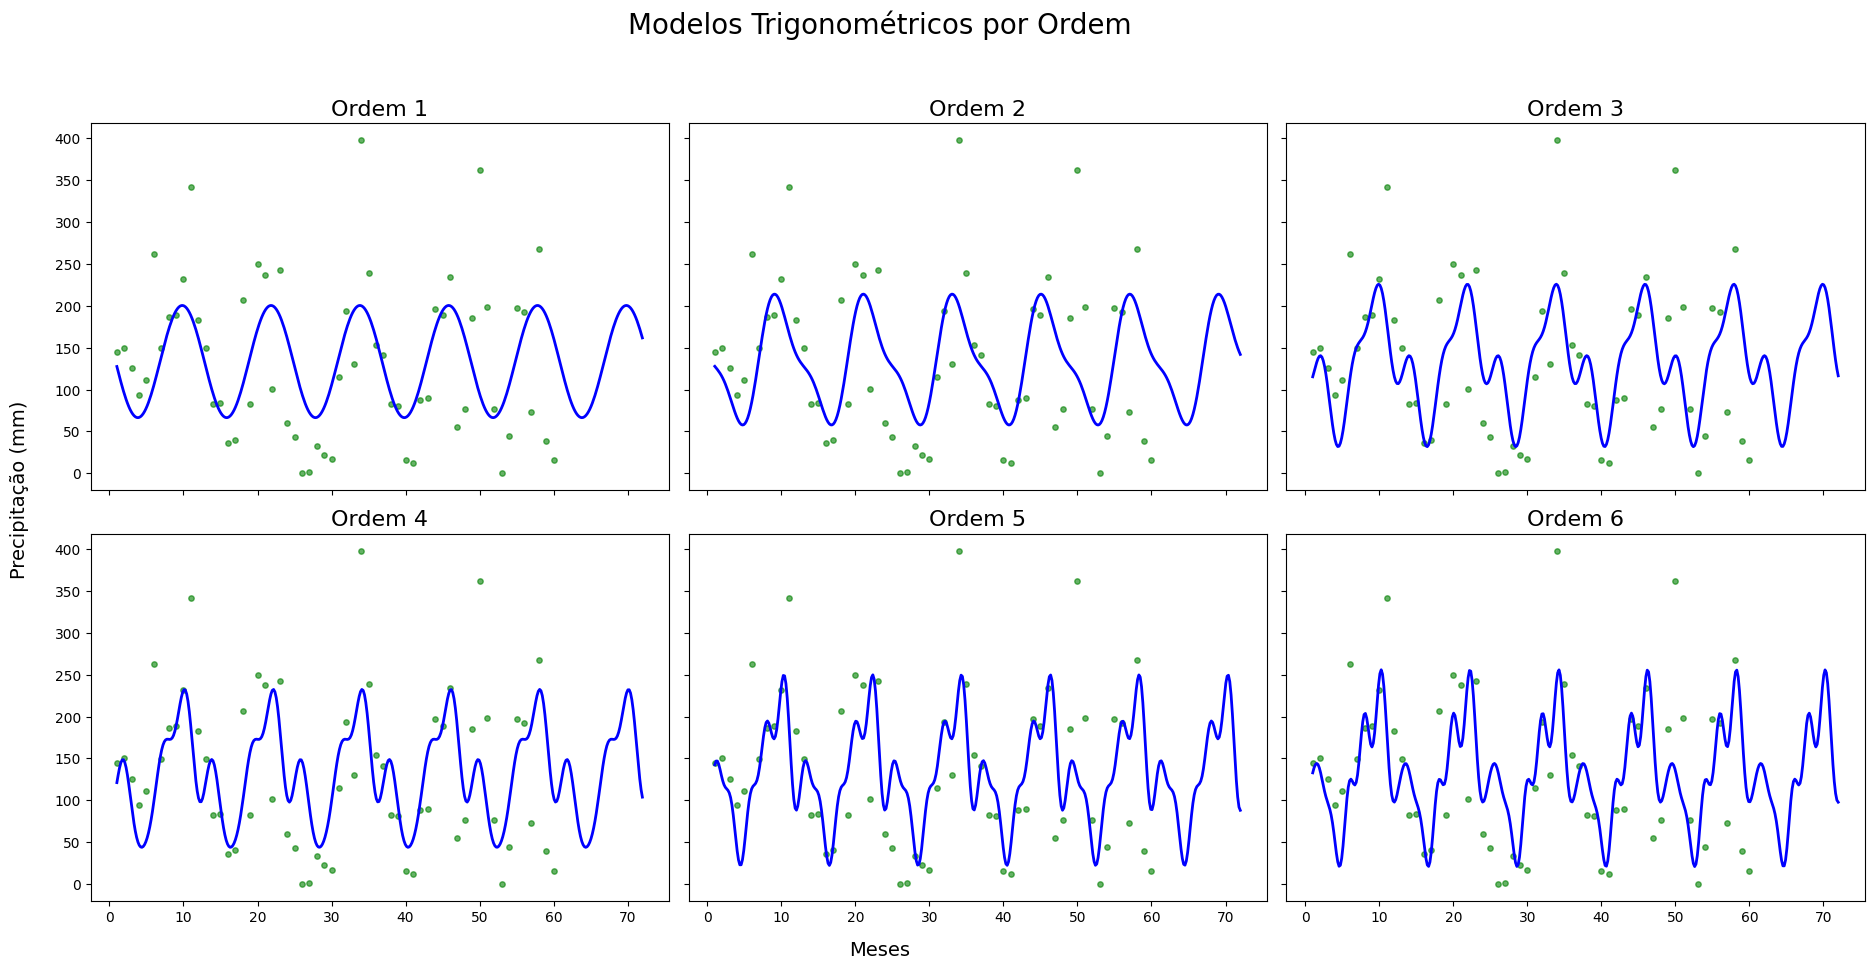

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Função de Modelo Trigonométrico Geral (a mesma de antes) ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        y += Ak * np.cos(2 * np.pi * ordem_k * x / 12) + Bk * np.sin(2 * np.pi * ordem_k * x / 12)
    return y

# --- Estrutura Principal do Gráfico com Subplots ---

# 1. Criar uma figura e uma grade de eixos 2x3.
# `sharex=True` e `sharey=True` fazem com que todos os gráficos tenham a mesma escala.
fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharex=True, sharey=True)

# Adicionar um título principal para a figura inteira
fig.suptitle('Modelos Trigonométricos por Ordem', fontsize=20)

# 2. Loop para preencher cada subplot
for ordem in range(1, 7): # De 1 a 6
    # Calcular a posição do subplot na grade (linha e coluna)
    row = (ordem - 1) // 3
    col = (ordem - 1) % 3
    ax = axs[row, col] # Seleciona o subplot atual

    num_params = 1 + 2 * ordem
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem)

    try:
        # Ajustar o modelo para a ordem atual
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        
        # Gerar a curva suave para o plot
        x_curva = np.linspace(1, 72, 400)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        
        # Plotar os dados e a curva NO SUBPLOT ATUAL (usando 'ax.')
        ax.scatter(x_dados, y_dados, color='green', alpha=0.6, s=15)
        ax.plot(x_curva, y_curva, color='blue', linewidth=2)
        
        
        # Calcular e imprimir a previsão
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        print(f"Ordem {ordem}: {precipitacao_prevista:.2f} mm")

        ax.set_title(f'Ordem {ordem}', fontsize=16)

    except RuntimeError:
        ax.set_title(f'Ordem {ordem} - Falha no Ajuste', color='red')
        print(f"Ordem {ordem}: Não foi possível ajustar o modelo.")

# 3. Adicionar rótulos comuns para a figura inteira
fig.text(0.5, 0.04, 'Meses', ha='center', va='center', fontsize=14)
fig.text(0.07, 0.5, 'Precipitação (mm)', ha='center', va='center', rotation='vertical', fontsize=14)
fig.legend(['dados originais'], ['modelo ajustado'])

# Ajustar o layout para evitar sobreposição
plt.tight_layout(rect=[0.08, 0.05, 1, 0.95]) # Ajusta a posição para dar espaço aos rótulos e título

plt.show()

Ordem 1: Previsão para o mês 72 = 161.60 mm
Ordem 2: Previsão para o mês 72 = 141.88 mm
Ordem 3: Previsão para o mês 72 = 116.34 mm
Ordem 4: Previsão para o mês 72 = 103.82 mm
Ordem 5: Previsão para o mês 72 = 88.10 mm


C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\1380445928.py:44: OptimizeWarning: Covariance of the parameters could not be estimated
  params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)


Ordem 6: Previsão para o mês 72 = 97.78 mm


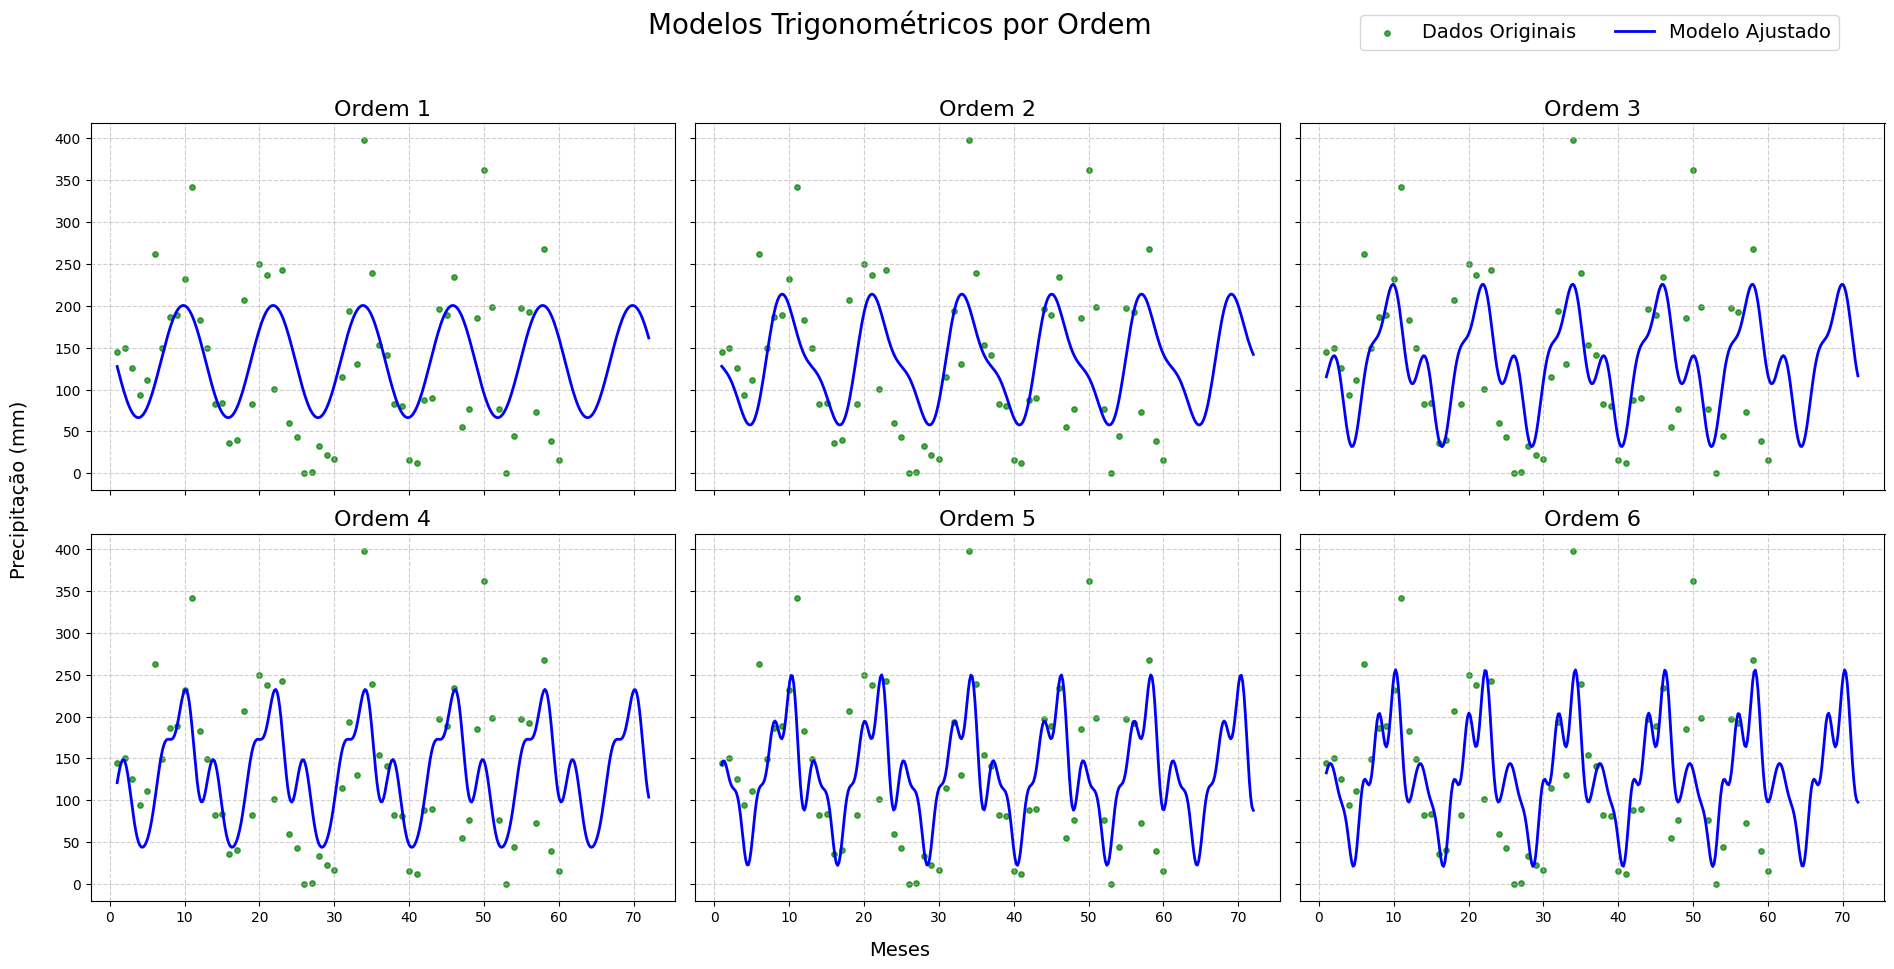

In [190]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Função de Modelo Trigonométrico Geral (a mesma de antes) ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        y += Ak * np.cos(2 * np.pi * ordem_k * x / 12) + Bk * np.sin(2 * np.pi * ordem_k * x / 12)
    return y

# --- Estrutura Principal do Gráfico com Subplots ---

# 1. Criar uma figura e uma grade de eixos 2x3.
fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharex=True, sharey=True)

# Adicionar um título principal para a figura inteira
fig.suptitle('Modelos Trigonométricos por Ordem', fontsize=20)

# 2. Loop para preencher cada subplot
for ordem in range(1, 7): # De 1 a 6
    row = (ordem - 1) // 3
    col = (ordem - 1) % 3
    ax = axs[row, col]

    num_params = 1 + 2 * ordem
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem)

    try:
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        x_curva = np.linspace(1, 72, 400)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        
        # Plotar os dados e a curva com labels
        # Os labels serão usados para a legenda geral
        ax.scatter(x_dados, y_dados, color='green', alpha=0.7, s=15, label='Dados Originais')
        ax.plot(x_curva, y_curva, color='blue', linewidth=2, label='Modelo Ajustado')
        
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        print(f"Ordem {ordem}: Previsão para o mês 72 = {precipitacao_prevista:.2f} mm")
        
        ax.grid(True, linestyle='--', alpha=0.6)

        ax.set_title(f'Ordem {ordem}', fontsize=16)

    except RuntimeError:
        ax.set_title(f'Ordem {ordem} - Falha no Ajuste', color='red')
        print(f"Ordem {ordem}: Não foi possível ajustar o modelo.")

# 3. Adicionar rótulos comuns para a figura inteira
fig.text(0.5, 0.04, 'Meses', ha='center', va='center', fontsize=14)
fig.text(0.06, 0.5, 'Precipitação (mm)', ha='center', va='center', rotation='vertical', fontsize=14)

# 4. Criar a legenda geral
# Captura os "handles" (as linhas/pontos) e "labels" (os textos) de um dos subplots
# Como eles são os mesmos para todos os gráficos, podemos pegar de qualquer um (ex: axs[0,0])
handles, labels = axs[0,0].get_legend_handles_labels()

# Cria a legenda na figura, posicionada na parte inferior central, com 2 colunas
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.85, 0.93), ncol=2, fontsize=14)

# Ajustar o layout para evitar sobreposição
# O valor de 'bottom' em rect foi ajustado para dar espaço para a legenda
plt.tight_layout(rect=[0.07, 0.05, 1, 0.95]) 

plt.show()

--- Previsão com Spline Cúbica ---
A precipitação estimada para o mês 72 é: 411014.41 mm


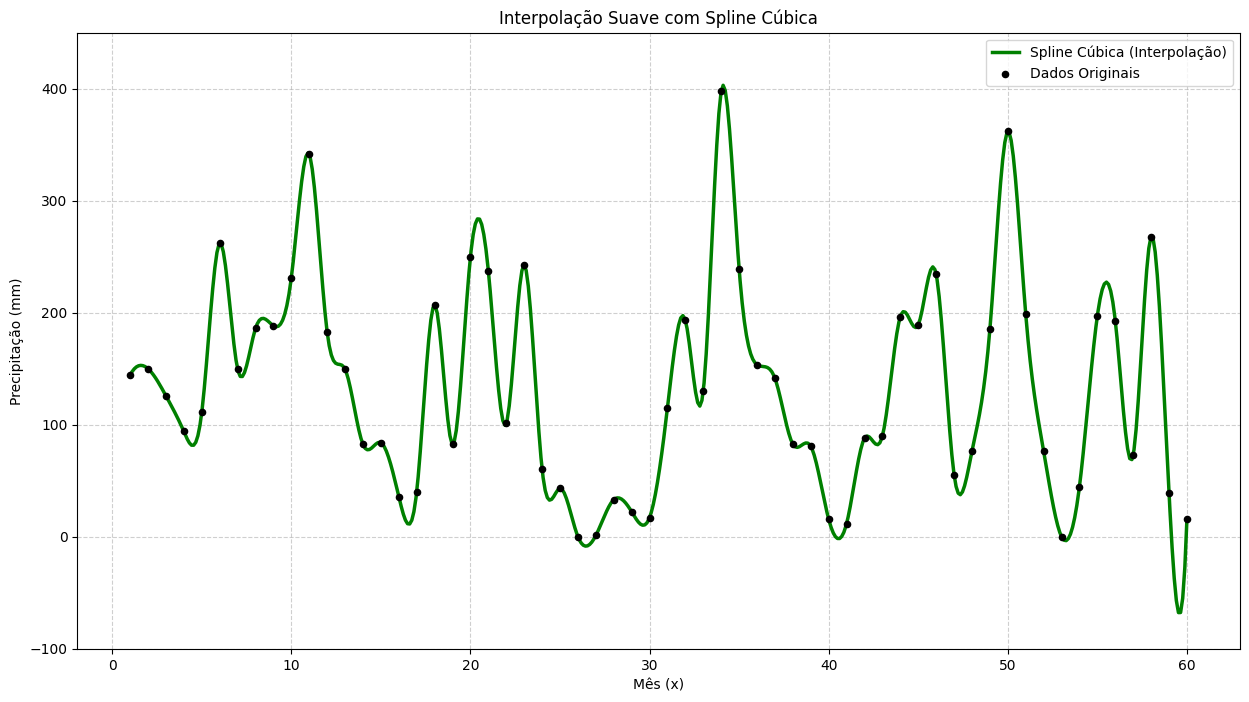

In [166]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Criando a função de Spline Cúbica ---
# A função é criada uma vez e pode ser usada para calcular qualquer ponto.
cs = CubicSpline(x_dados, y_dados)

# --- Previsão para o mês 72 (Extrapolação) ---
mes_futuro = 72
# A extrapolação usará o polinômio do último intervalo (entre os meses 59 e 60)
precipitacao_prevista = cs(mes_futuro)

print(f"--- Previsão com Spline Cúbica ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:.2f} mm")

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Curva da Interpolação (dentro do intervalo 1-60)
x_interp = np.linspace(1, 60, 500)
y_interp = cs(x_interp)
plt.plot(x_interp, y_interp, label='Spline Cúbica (Interpolação)', color='green', linewidth=2.5)

# Curva da Extrapolação (depois do mês 60)
# x_extrap = np.linspace(60, 72, 100)
# y_extrap = cs(x_extrap)
# plt.plot(x_extrap, y_extrap, label='Extrapolação da Spline', color='red', linestyle='--')

# Dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='black', s=20, zorder=5)
plt.title('Interpolação Suave com Spline Cúbica')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(-100,450)
plt.show()

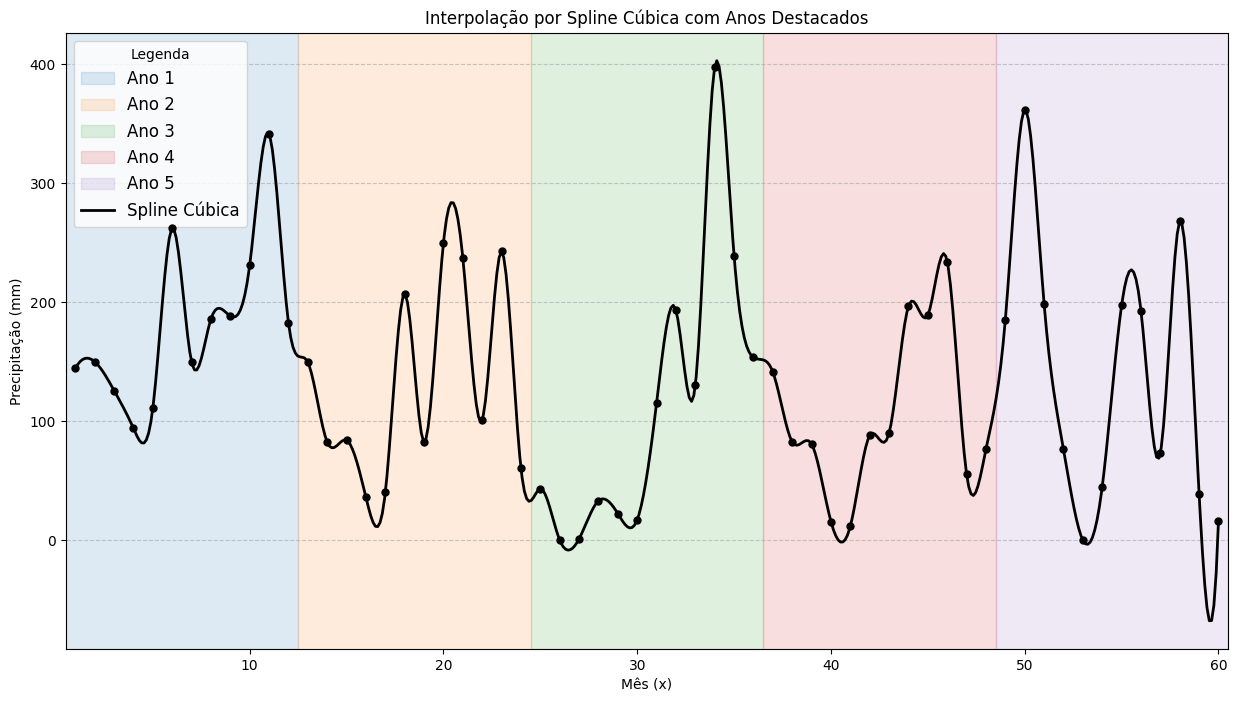

In [167]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Passo 1: Criar a função de Spline Cúbica ---
# A função é criada uma vez e pode ser usada para calcular qualquer ponto.
cs = CubicSpline(x_dados, y_dados)

# --- Passo 2: Estrutura Principal do Gráfico ---
plt.figure(figsize=(15, 8))
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Azul, Laranja, Verde, Vermelho, Roxo
numero_de_anos = 5

# Loop para sombrear o fundo de cada ano com faixas verticais
for ano in range(numero_de_anos):
    # O `axvspan` cria um retângulo vertical semi-transparente
    plt.axvspan(xmin=ano * 12 + 0.5, xmax=(ano + 1) * 12 + 0.5, 
                color=cores[ano], 
                alpha=0.15, # Baixa opacidade para dar o efeito de sombreamento
                label=f'Ano {ano + 1}') # O label será usado na legenda

# --- Passo 3: Plotar o modelo e os dados por cima do fundo ---

# Curva da Spline Cúbica (a linha principal)
x_curva = np.linspace(1, 60, 500)
y_curva = cs(x_curva)
plt.plot(x_curva, y_curva, color='black', label='Spline Cúbica', linewidth=2, zorder=10)

# Dados Originais (os pontos)
plt.scatter(x_dados, y_dados, color='black', s=25, zorder=11) # zorder alto para ficar na frente

# --- Passo 4: Configurações finais do gráfico ---
plt.title('Interpolação por Spline Cúbica com Anos Destacados')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.xlim(0.5, 60.5) # Ajusta o limite do eixo X para ficar mais justo
plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Legenda", fontsize=12)
plt.show()